In [1]:
from random import randint, uniform

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Input

Vamos gerar uma base de dados de 2 mil linhas, com duas colunas idades e salários.

* Idade vai variar entre 18 e 95.
* Salarios vai variar entre 1300 e 100000

In [2]:
idades = [randint(18, 95) for _ in range(2000)]
salarios = [uniform(1300, 100000) for _ in range(2000)]

df = pd.DataFrame(zip(idades, salarios), columns=["idade", "salario"])

df.head()

,idade,salario
0,32,64077.141607
1,67,61217.712089
2,34,23178.484812
3,94,69037.027972
4,51,10525.615176


<Axes: xlabel='idade', ylabel='salario'>

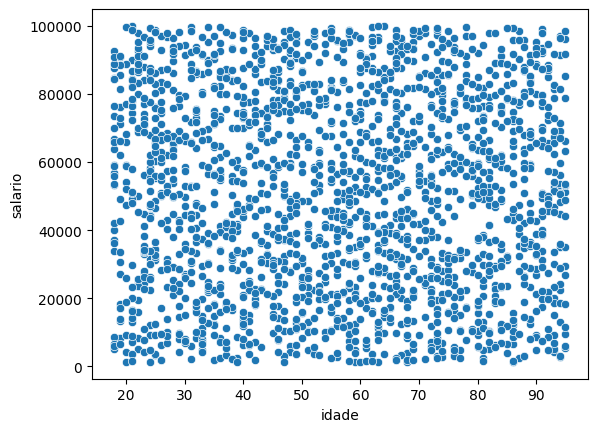

In [3]:
sns.scatterplot(x="idade", y="salario", data=df)

Text(0.5, 1.0, 'Número de pessoas por salário')

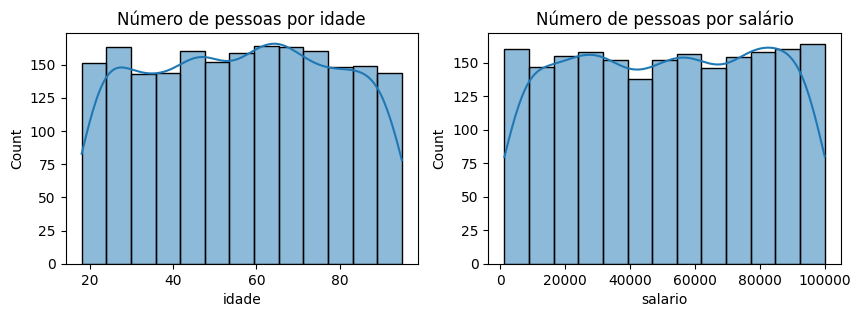

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

sns.histplot(data=df["idade"], kde=True, ax=axes[0])
axes[0].set_title('Número de pessoas por idade')

sns.histplot(data=df["salario"], kde=True, ax=axes[1])
axes[1].set_title('Número de pessoas por salário')

* Vídeo didático explicando o funcionando do kmeans:

https://youtu.be/OWyWevKhM0c?si=WqtawW-cgtNtXRQo

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

X = df[["idade", "salario"]]

kmeans.fit(X)

KMeans(n_clusters=4, random_state=42)

In [6]:
kmeans.max_iter

300

In [7]:
centroides = kmeans.cluster_centers_

centroides

array([[5.64357430e+01, 6.17326078e+04],
       [5.67066116e+01, 1.31425394e+04],
       [5.56819853e+01, 8.71436611e+04],
       [5.67890295e+01, 3.70367853e+04]])

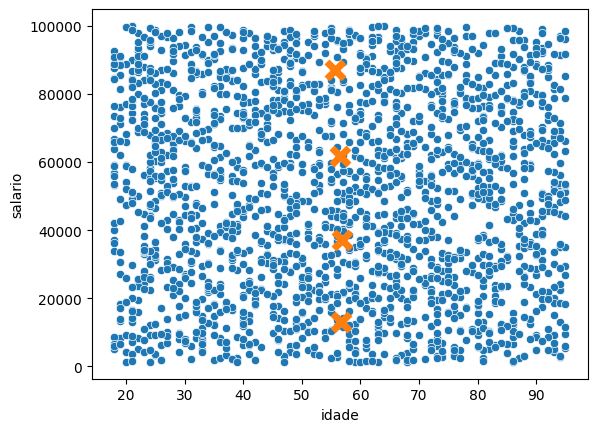

In [8]:
sns.scatterplot(x="idade", y="salario", data=df)
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [9]:
df["cluster"] = kmeans.predict(df[["idade", "salario"]])
df.head()

,idade,salario,cluster
0,32,64077.141607,0
1,67,61217.712089,0
2,34,23178.484812,1
3,94,69037.027972,0
4,51,10525.615176,1


In [10]:
df.groupby("cluster").mean()

,idade,salario
cluster,,
0,56.524950,61659.095582
1,56.687371,13117.693743
2,55.681985,87143.661116
3,56.716102,36932.650471


## Feature Scaling

### Normalização
* Usa como "escalonador" o valor mínimo e o valor máximo
* Varia entre 0 e 1
* "Achata" os dados, ou seja, outliers perdem seu poder de influência
* São indicados para os casos onde se tem distribuições normais nos dados;

### Padronização
* Usa como "escalonador" o valor da média e o desvio padrão
* Pode ter valores negativos
* Consegue representar mais a variabilidade dos dados
* São indicados para os casos onde não se tem distribuições normais nos dados;



## Como saber se os dados seguem uma distribuição normal?

1) Gráficos

2) Teste de normalidade

* **Hipotese nula**: Os dados seguem distribuição normal
* **Hipotese alternativa**: Os dados não seguem distribuição normal


**k2 (chi-squared statistic)**:

Este valor é, na verdade, a soma de dois termos elevados ao quadrado: s² + k². Sendo s o valor z obtido através do teste de assimetria (skewtest) e k é o valor da estatística z obtido pelo teste de curtose.

**p (p-value)**:

É a probabilidade de se obter um efeito tão extremo quanto o que está ocorrendo em nossos dados, assumindo que a hipótese nula é verdadeira. (Qual a probabilidade da distribuição que observamos naquele histograma ocorrer? Este é o p-valor)

**alpha**:


Qual o nível de erro que aceitamos em nosso teste? Rejeitamos a hipótese nula quando o valor-p for menor do que o nível de significância do nosso teste

In [11]:
from scipy.stats import normaltest

k2, p = normaltest(df['salario'])

alpha = 0.05 # 5% Se a probabilidade for menor que 5% então vamos rejeitar a hipótese nula

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

1995.4024542756108 0.0
A Hipótese nula pode ser rejeitada


In [ ]:
from scipy.stats import normaltest

k2, p = normaltest(df['idade'])

alpha = 0.05

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

1794.2488379042993 0.0
A Hipótese nula pode ser rejeitada


In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler() #chamando o metodo de padronização dos dados (média e std)

dados_input = df[["idade", "salario"]]
scaler.fit(dados_input)

dados_input_scaled = scaler.transform(dados_input)

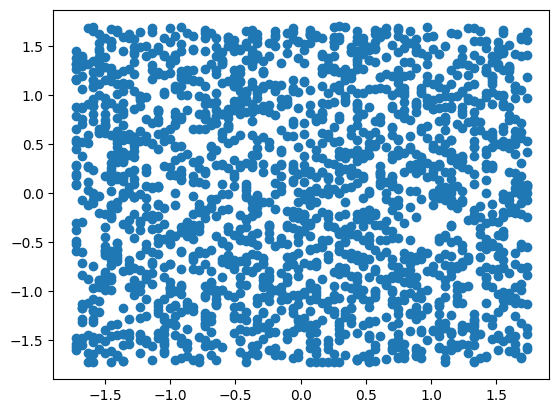

In [14]:
plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])

In [ ]:
dados_input_scaled

array([[-0.27587448, -0.44083744],
       [-1.67636724, -0.50220778],
       [-0.72764634, -1.70282505],
       ...,
       [-0.90835509,  1.02857216],
       [-1.13424101,  1.57786445],
       [ 1.21497265,  1.18796225]])

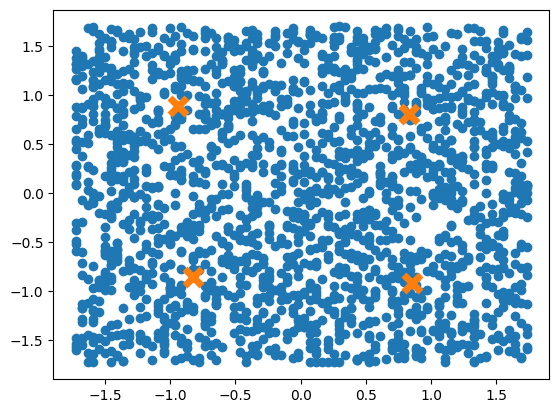

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(dados_input_scaled)

centroides = kmeans.cluster_centers_

plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [ ]:
dados_input_scaled

array([[0.64935065, 0.68544839],
       [0.2987013 , 0.37399736],
       [0.14285714, 0.12657397],
       ...,
       [0.18181818, 0.53050422],
       [0.05194805, 0.69301691],
       [0.71428571, 0.74974538]])

In [17]:
kmeans.predict(dados_input_scaled)

array([0, 2, 1, ..., 0, 3, 1], dtype=int32)

In [16]:
df["cluster_padronizado"] = kmeans.predict(dados_input_scaled)
df.groupby("cluster_padronizado").mean()

,idade,salario,cluster
cluster_padronizado,,,
0,35.568465,76777.294673,1.141079
1,37.965795,26338.828234,1.925553
2,74.909259,74322.614714,0.996296
3,75.459459,24603.222503,1.958420


In [ ]:
df.head()

,idade,salario,cluster,cluster_padronizado
0,29,46999.205184,1,1
1,85,93125.247445,0,3
2,72,27328.721767,1,2
3,65,16410.340646,3,2
4,40,6793.311852,3,1


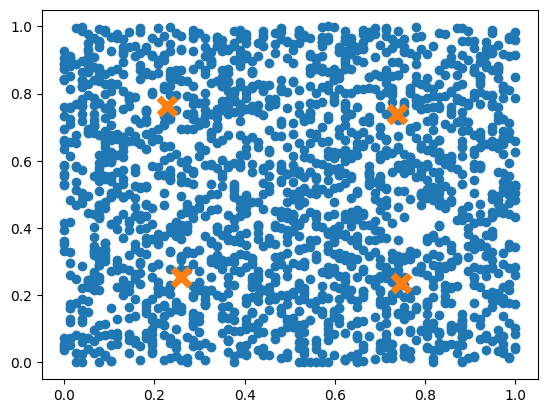

In [18]:
scaler = MinMaxScaler()

dados_input = df[["idade", "salario"]]
scaler.fit(dados_input)

dados_input_scaled = scaler.transform(dados_input)

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(dados_input_scaled)

centroides = kmeans.cluster_centers_

plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [19]:
df["cluster_normalizado"] = kmeans.predict(dados_input_scaled)

df

,idade,salario,cluster,cluster_padronizado,cluster_normalizado
0,32,64077.141607,0,0,0
1,67,61217.712089,0,2,2
2,34,23178.484812,1,1,1
3,94,69037.027972,0,2,2
4,51,10525.615176,1,1,1
...,...,...,...,...,...
1995,21,57862.522799,0,0,0
1996,45,76722.939685,2,0,0
1997,24,86775.631035,2,0,0
1998,94,35970.220517,3,3,3


In [20]:
df.loc[df.cluster_normalizado != df.cluster_padronizado]

,idade,salario,cluster,cluster_padronizado,cluster_normalizado
227,55,71435.403572,0,0,2


In [ ]:
df.groupby("cluster_normalizado").mean()

,idade,salario,cluster,cluster_padronizado
cluster_normalizado,,,,
0,76.726908,27071.483140,1.030120,0.002008
1,74.506250,76925.206313,2.029167,1.000000
2,38.464151,25967.204708,0.992453,1.992453
3,36.288618,75382.794325,1.997967,2.997967


# Pontos importantes

* Feature scaling é importante para algoritmos que utilizam distância e redes neurais;
* A avaliação do resultado de uma clusterização é feita analisando a distribuição dos dados nos grupos

# Método do Cotovelo (Elbow Method)

A ideia é:

* Rodar o KMeans para vários valores de 𝑘 k (por exemplo, de 1 a 10).

* Calcular a soma dos erros quadráticos dentro dos clusters (WCSS) para cada
𝑘 k.

* Plotar o gráfico de  𝑘 k vs WCSS.

* Procurar o “cotovelo” da curva — o ponto onde a redução no WCSS começa a diminuir drasticamente.

https://medium.com/pizzadedados/kmeans-e-metodo-do-cotovelo-94ded9fdf3a9

O atributo kmeans.inertia_ no scikit-learn retorna a soma dos quadrados das distâncias (distância euclidiana ao quadrado) entre cada ponto de dados e o centroide do seu cluster.

**O que isso significa na prática?**

Qualidade do Agrupamento: A inércia mede o quão "compactos" são os seus clusters. Quanto menor a inércia, mais próximos os pontos estão dos seus respectivos centroides, indicando um agrupamento mais coeso

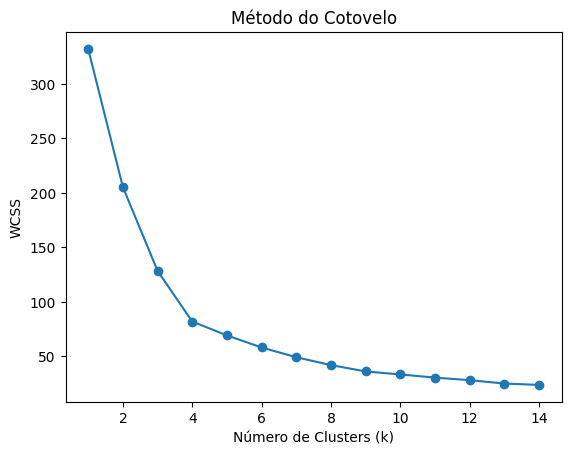

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] # Within-Cluster Sum of Squares
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(dados_input_scaled)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS

plt.plot(range(1, 15), wcss, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo')
plt.show()


## Extra: Comprovando os resultados do teste de normalidade

(array([  5.,  42., 155., 332., 473., 493., 318., 133.,  41.,   8.]),
 array([-3.289338  , -2.62849034, -1.96764268, -1.30679502, -0.64594735,
         0.01490031,  0.67574797,  1.33659563,  1.99744329,  2.65829095,
         3.31913861]),
 <BarContainer object of 10 artists>)

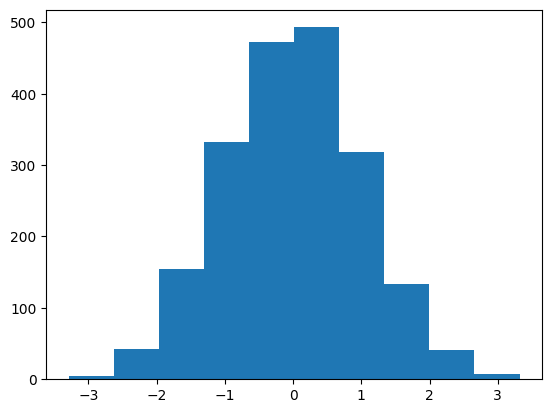

In [ ]:
from random import gauss

sigma = 1
media = 0

valores_normais = [gauss(media, sigma) for i in range(0, 2000)]
plt.hist(valores_normais)

In [ ]:
from scipy.stats import normaltest

k2, p = normaltest(valores_normais)

alpha = 0.05

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

1.6742976906138185 0.43294315328820265
A hipótese nula não pode ser rejeitada


Exemplo com pipeline que gerei aqui com o gemini


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import pickle

# 1. Generate fictional data
np.random.seed(42) # for reproducibility
data = {
    'Age': np.random.randint(20, 90, 100),
    'Salary': np.random.randint(30000, 120000, 100)
}
X = pd.DataFrame(data)

# 2. Preprocess data
# Instantiate a StandardScaler object
scaler = StandardScaler()

# 3. Create pipeline
# Instantiate a KMeans object
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Create a pipeline with the scaler and the KMeans model
pipeline = Pipeline([
    ('scaler', scaler),
    ('kmeans', kmeans)
])

# 4. Train model
# Fit the pipeline to the data
pipeline.fit(X)
print(pipeline.predict([[20,300000]]))

# 5. Export pipeline
filename = 'kmeans_pipeline.pkl'
pickle.dump(pipeline, open(filename, 'wb'))

print(f"Pipeline exported to {filename}")

[1]
Pipeline exported to kmeans_pipeline.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
